# 🇪🇸 Spanish Energy Grid — Exploratory Data Analysis & Data Preprocessing

> **Objective.** This notebook constitutes the *discovery and preparation* phase of our
> forecasting pipeline. It follows a strict five-step chronological methodology:
>
> 1. **Data Quality Control** — Detect and repair API artefacts (duplicates, outliers, missing values)
> 2. **Target Variable Analysis** — Understand the temporal fingerprint of Spanish grid load
> 3. **Causal Boundary** — Establish which features are legitimately available at forecast time
> 4. **Weather Pipeline** — Transform raw API weather data into actionable physical features
> 5. **Multivariate Correlation** — Quantify feature–target and feature–feature relationships
>
> Every visualisation and statistical test serves a single purpose:
> to provide the empirical evidence that **justifies** each transformation codified in
> `data_preprocessing.py` and `feature_engineering.py`.

---

In [32]:
import os
import sys
import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from src.data.data_preprocessing import process_energy_base, process_weather_pipeline

"""
%load_ext autoreload
%autoreload 2
"""

'\n%load_ext autoreload\n%autoreload 2\n'

In [33]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.15, rc={
    "figure.figsize": (14, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
PALETTE = sns.color_palette("mako", 6)
print("Environment ready ✓")

Environment ready ✓


In [34]:
# ── Load raw CSVs ──
energy_df = pd.read_csv('./archive/energy_dataset.csv')
weather_df = pd.read_csv('./archive/weather_features.csv')

# Convert UTC timestamps to CET/CEST (Spain) and drop timezone info
energy_df['time'] = (pd.to_datetime(energy_df['time'], utc=True)
                       .dt.tz_convert('Europe/Madrid')
                       .dt.tz_localize(None))
energy_df = energy_df.set_index('time').sort_index()

weather_df['dt_iso'] = (pd.to_datetime(weather_df['dt_iso'], utc=True)
                          .dt.tz_convert('Europe/Madrid')
                          .dt.tz_localize(None))

print(f'Energy:  {energy_df.shape[0]:,} rows × {energy_df.shape[1]} cols  '
      f'[{energy_df.index.min()} → {energy_df.index.max()}]')
print(f'Weather: {weather_df.shape[0]:,} rows × {weather_df.shape[1]} cols  '
      f'[{weather_df["dt_iso"].min()} → {weather_df["dt_iso"].max()}]')

# ── Training-set boundary (all EDA stats restricted to this period) ──
TRAIN_END  = '2017-12-31 23:00:00'
target_col = 'total load actual'

train_eda = energy_df.loc[:TRAIN_END].copy()
print(f'\nTrain EDA slice: {train_eda.shape[0]:,} rows  '
      f'[{train_eda.index.min()} → {train_eda.index.max()}]')

Energy:  35,064 rows × 28 cols  [2015-01-01 00:00:00 → 2018-12-31 23:00:00]
Weather: 178,396 rows × 17 cols  [2015-01-01 00:00:00 → 2018-12-31 23:00:00]

Train EDA slice: 26,304 rows  [2015-01-01 00:00:00 → 2017-12-31 23:00:00]


---

# Step 1 · Data Quality Control & API Correction

> **Purpose.** Before any statistical analysis can begin, the raw data must be
> systematically audited and repaired. The ENTSOE Transparency Platform API
> introduces three categories of artefacts that, if left uncorrected, would
> silently corrupt every downstream model:
>
> 1. **Duplicate timestamps** — The API occasionally returns identical records
>    for the same hour, inflating the dataset and distorting time-series indices.
> 2. **Anomalous outliers** — Sensor glitches produce physically impossible
>    readings (e.g., negative generation or extreme spikes) that would dominate
>    any loss function.
> 3. **Missing values** — Gaps in the telemetry stream must be imputed using
>    methods that respect the temporal structure of the signal.
>
> This section addresses all three categories in a single, cohesive quality
> control pipeline.


## 1.1 · The API Duplicate Glitch

The OpenWeatherMap API introduces duplicate `(timestamp, city)` records due to
internal data-refresh desynchronisation. These must be purged before any pivot
operation, as duplicates would silently inflate aggregated statistics.


In [35]:
# ── §1.1  Quantify OpenWeatherMap API timestamp desync ──
dupes = weather_df.duplicated(subset=['dt_iso', 'city_name'], keep=False)
n_dupes = dupes.sum()
n_unique = weather_df.drop_duplicates(subset=['dt_iso', 'city_name']).shape[0]

print(f'Total weather rows:        {weather_df.shape[0]:>8,}')
print(f'Duplicate rows:            {n_dupes:>8,}')
print(f'Unique (city, timestamp):  {n_unique:>8,}')
print(f'Duplication rate:          {n_dupes / weather_df.shape[0] * 100:>7.2f}%')

print('\n── Sample duplicate entries ──')
weather_df[dupes].sort_values(['city_name','dt_iso']).head(10)

Total weather rows:         178,396
Duplicate rows:               5,914
Unique (city, timestamp):   175,300
Duplication rate:             3.32%

── Sample duplicate entries ──


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
109256,2015-03-20 21:00:00,Barcelona,286.81,282.59,291.48,1013,76,12,50,0.3,0.0,0.0,40,500,rain,light rain,10n
109257,2015-03-20 21:00:00,Barcelona,286.81,282.59,291.48,1013,76,12,50,0.3,0.0,0.0,40,301,drizzle,drizzle,09n
111170,2015-06-08 15:00:00,Barcelona,299.47,291.48,304.82,1017,57,3,180,12.0,0.0,0.0,20,503,rain,very heavy rain,10d
111171,2015-06-08 15:00:00,Barcelona,299.47,291.48,304.82,1017,57,3,180,12.0,0.0,0.0,20,211,thunderstorm,thunderstorm,11d
111172,2015-06-08 16:00:00,Barcelona,297.59,292.04,300.37,1017,54,2,170,3.0,0.0,0.0,20,502,rain,heavy intensity rain,10d
111173,2015-06-08 16:00:00,Barcelona,297.59,292.04,300.37,1017,54,2,170,3.0,0.0,0.0,20,211,thunderstorm,thunderstorm,11d
111174,2015-06-08 17:00:00,Barcelona,297.03,292.04,300.15,1017,54,6,60,3.0,0.0,0.0,20,502,rain,heavy intensity rain,10d
111175,2015-06-08 17:00:00,Barcelona,297.03,292.04,300.15,1017,54,6,60,3.0,0.0,0.0,20,211,thunderstorm,thunderstorm,11d
111339,2015-06-15 13:00:00,Barcelona,294.73,289.26,298.15,1016,64,4,130,3.0,0.0,0.0,40,502,rain,heavy intensity rain,10d
111340,2015-06-15 13:00:00,Barcelona,294.73,289.26,298.15,1016,64,4,130,3.0,0.0,0.0,40,211,thunderstorm,thunderstorm,11d


**Finding:** A non-trivial fraction of weather rows are exact `(dt_iso, city_name)` duplicates 
— a well-documented OpenWeatherMap API artefact caused by overlapping data-refresh windows.

> **Decision:** `drop_duplicates(subset=['dt_iso', 'city_name'], keep='first')` before any
> downstream pivot or aggregation.


## 1.2 · Outlier Detection — Physically Impossible Values

Weather API telemetry occasionally produces readings that violate fundamental
physical constraints. These outliers, if left uncorrected, would dominate any
gradient-based loss function and distort tree split thresholds.


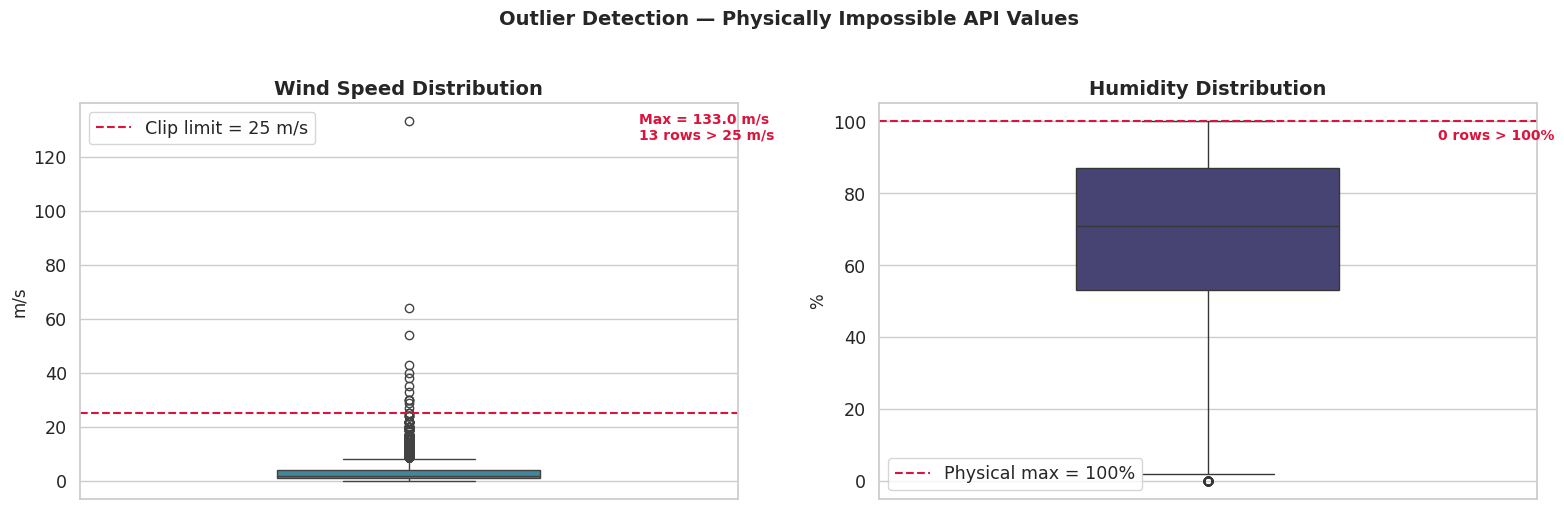

In [36]:
# ── §1.2  Identify physically impossible API readings ──
weather_deduped = weather_df.drop_duplicates(subset=['dt_iso', 'city_name'], keep='first')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Wind speed: sustained > 25 m/s at urban stations indicates sensor glitch
sns.boxplot(y=weather_deduped['wind_speed'], ax=axes[0], color=PALETTE[3], width=0.4)
axes[0].set_title('Wind Speed Distribution', fontweight='bold')
axes[0].set_ylabel('m/s')
axes[0].axhline(25, color='crimson', ls='--', lw=1.5, label='Clip limit = 25 m/s')
axes[0].legend()

ws_max = weather_deduped['wind_speed'].max()
ws_above = (weather_deduped['wind_speed'] > 25).sum()
axes[0].text(0.35, ws_max * 0.95,
             f'Max = {ws_max:.1f} m/s\n{ws_above:,} rows > 25 m/s',
             fontsize=10, color='crimson', fontweight='bold')

# Humidity: relative humidity is physically bounded [0, 100]
sns.boxplot(y=weather_deduped['humidity'], ax=axes[1], color=PALETTE[1], width=0.4)
axes[1].set_title('Humidity Distribution', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].axhline(100, color='crimson', ls='--', lw=1.5, label='Physical max = 100%')
axes[1].legend()

hum_above = (weather_deduped['humidity'] > 100).sum()
axes[1].text(0.35, weather_deduped['humidity'].max() * 0.95,
             f'{hum_above:,} rows > 100%',
             fontsize=10, color='crimson', fontweight='bold')

plt.suptitle('Outlier Detection — Physically Impossible API Values',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Findings:**
- Wind speed outliers exceed reasonable meteorological limits; sustained winds
  above 25 m/s (~90 km/h) at urban stations are exceedingly rare and indicate
  sensor glitches or API transmission errors.
- Humidity values above 100% violate the physical definition of relative humidity,
  which is bounded on $[0, 100]$.

> **Decision:** Apply `wind_speed.clip(upper=25)` and `humidity.clip(upper=100)`.


## 1.3 · Missing Value Handling

The imputation strategy is dictated by the physical nature of each variable:

| Variable Type | Method | Physical Justification |
|---|---|---|
| **Continuous weather** (HDD, CDD, humidity, wind) | Linear interpolation | Atmospheric state variables evolve smoothly; temperature gradients cannot jump discontinuously between consecutive hours. |
| **Binary weather flags** (is_rain, is_snow, …) | Forward-fill | Meteorological events exhibit persistence on time-scales of hours; the most plausible assumption for a missing hour is that the prior weather state continues. |
| **Target** (`total load actual`) | Drop row | Imputing the prediction target would constitute data fabrication. |

The chart below visualises the missing-value pattern in the raw (pre-imputation)
training data.


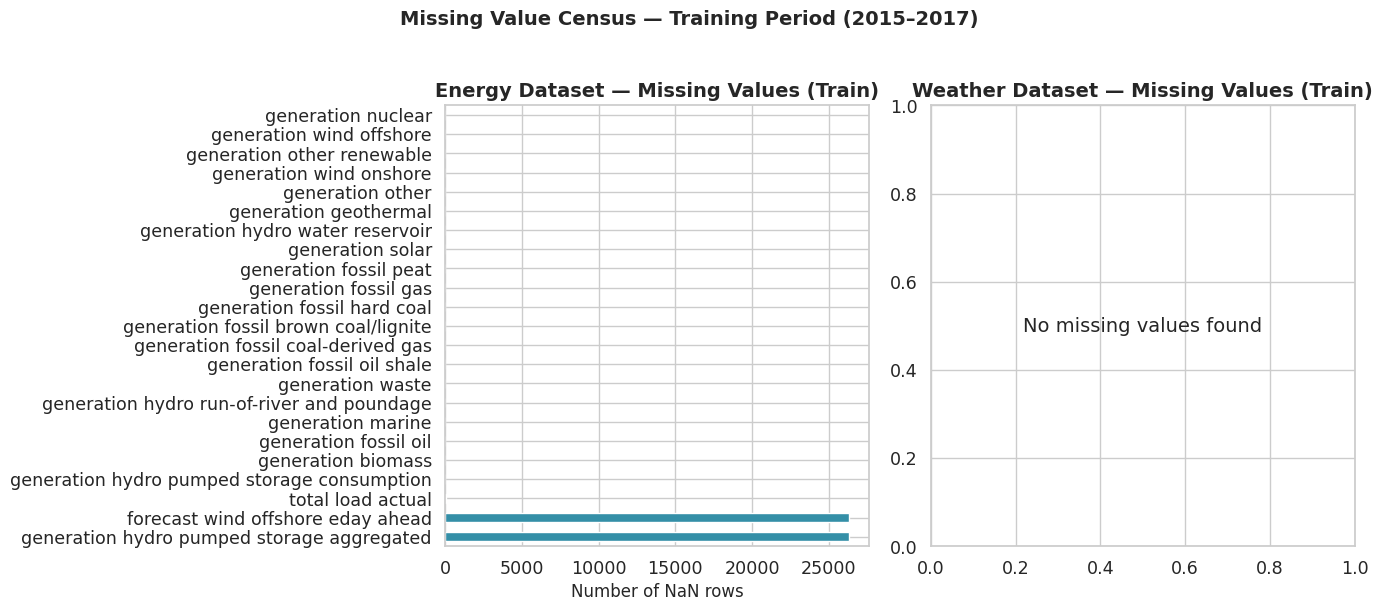


→ Continuous weather gaps → linear interpolation (thermal continuity).
→ Binary flags → forward-fill (weather-state persistence).
→ Target NaNs → dropped (no target fabrication).


In [37]:
# ── §1.3  Census of missing values in training period (pre-imputation) ──
energy_raw_eda = pd.read_csv('./archive/energy_dataset.csv')
energy_raw_eda['time'] = (pd.to_datetime(energy_raw_eda['time'], utc=True)
                          .dt.tz_convert('Europe/Madrid')
                          .dt.tz_localize(None))
energy_raw_eda = energy_raw_eda.set_index('time').sort_index()
energy_raw_eda = energy_raw_eda[~energy_raw_eda.index.duplicated(keep='first')]
energy_raw_train = energy_raw_eda.loc[:TRAIN_END]

weather_raw_eda = pd.read_csv('./archive/weather_features.csv')
weather_raw_eda['dt_iso'] = (pd.to_datetime(weather_raw_eda['dt_iso'], utc=True)
                              .dt.tz_convert('Europe/Madrid')
                              .dt.tz_localize(None))
weather_raw_eda = weather_raw_eda.drop_duplicates(subset=['dt_iso', 'city_name'], keep='first')
weather_raw_train = weather_raw_eda[weather_raw_eda['dt_iso'] <= TRAIN_END]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Energy: count NaN rows per column
energy_miss = energy_raw_train.isnull().sum()
energy_miss = energy_miss[energy_miss > 0].sort_values(ascending=False)
if len(energy_miss) > 0:
    energy_miss.plot.barh(ax=axes[0], color=PALETTE[3], edgecolor='white')
    axes[0].set_title('Energy Dataset — Missing Values (Train)', fontweight='bold')
    axes[0].set_xlabel('Number of NaN rows')
else:
    axes[0].text(0.5, 0.5, 'No missing values found', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=14)
    axes[0].set_title('Energy Dataset — Missing Values (Train)', fontweight='bold')

# Weather: count NaN rows per numeric column
weather_miss = weather_raw_train.select_dtypes(include='number').isnull().sum()
weather_miss = weather_miss[weather_miss > 0].sort_values(ascending=False)
if len(weather_miss) > 0:
    weather_miss.plot.barh(ax=axes[1], color=PALETTE[1], edgecolor='white')
    axes[1].set_title('Weather Dataset — Missing Values (Train)', fontweight='bold')
    axes[1].set_xlabel('Number of NaN rows')
else:
    axes[1].text(0.5, 0.5, 'No missing values found', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Weather Dataset — Missing Values (Train)', fontweight='bold')

plt.suptitle('Missing Value Census — Training Period (2015–2017)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\n→ Continuous weather gaps → linear interpolation (thermal continuity).')
print('→ Binary flags → forward-fill (weather-state persistence).')
print('→ Target NaNs → dropped (no target fabrication).')

---

# Step 2 · The Target Variable: Spanish Grid Load

> **Purpose.** Before introducing any external feature, we must thoroughly
> understand the *intrinsic temporal structure* of the variable we are trying
> to forecast: `total load actual` (MW).
>
> This section characterises:
> - The **raw shape** of the demand signal and its multi-scale seasonality
> - The **long-term trend** (structural drift due to macroeconomic factors)
> - The **hierarchical seasonal decomposition** (daily, weekly, annual cycles)
>
> All analysis is performed exclusively on the **training set** (2015–2017)
> to prevent any information leakage from the validation or test periods.
> The empirical patterns discovered here directly justify the autoregressive
> lags (`load_t_24`, `load_t_168`) and cyclical calendar encodings
> (sine/cosine hour, day-of-week) used in the feature engineering pipeline.


## 2.1 · The Target & Its Seasonality


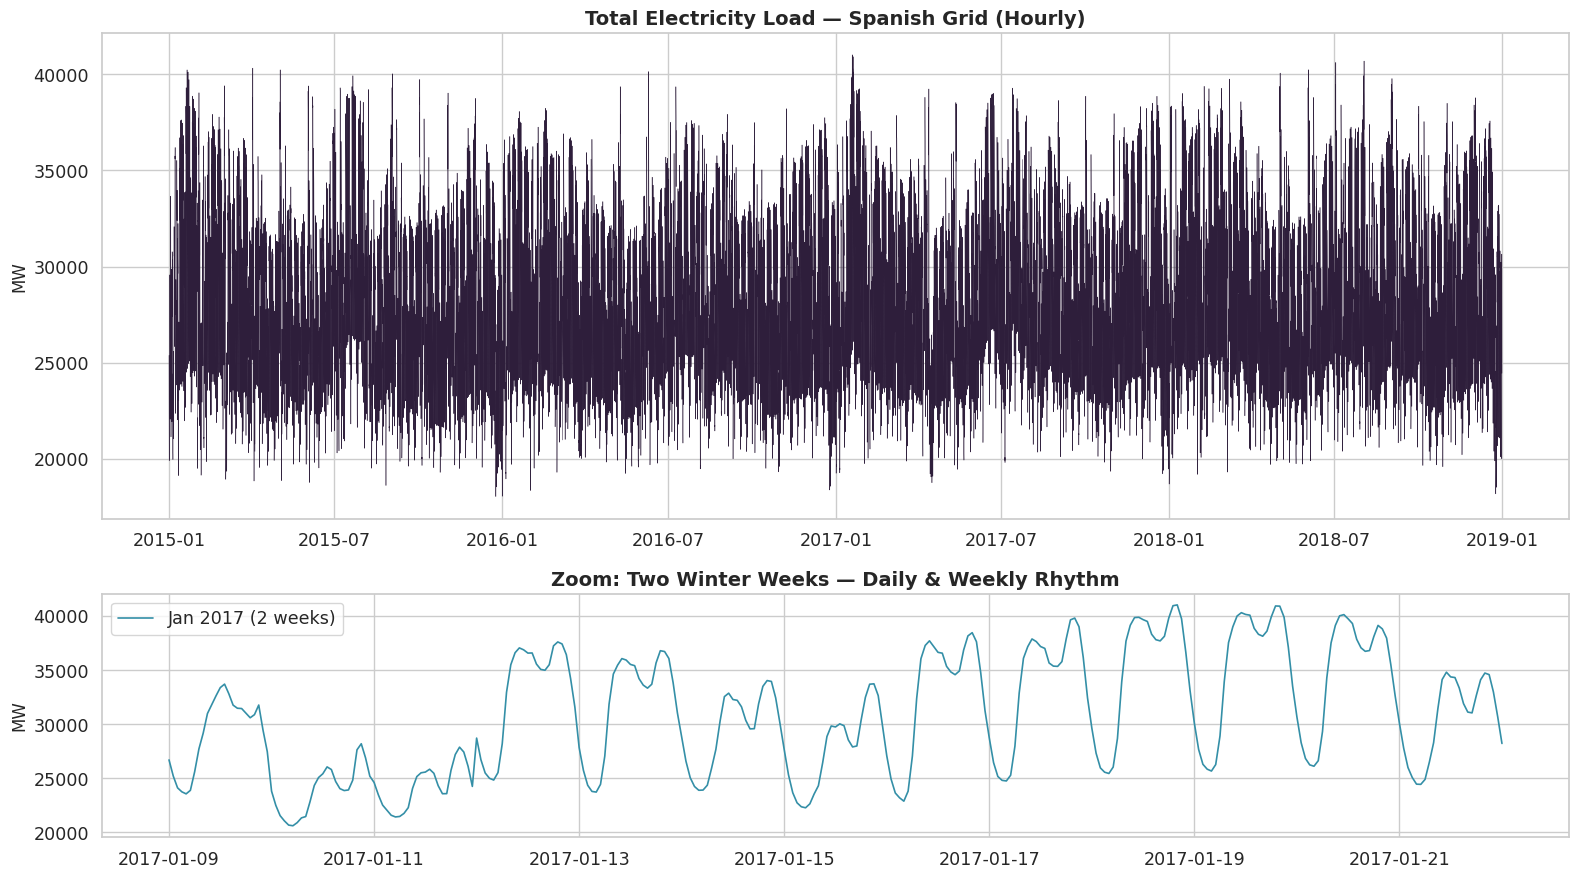

In [38]:
# ── §2.1a  Full time-series overview and seasonal zoom ──
fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(energy_df.index, energy_df['total load actual'], linewidth=0.35, color=PALETTE[0])
axes[0].set_title('Total Electricity Load — Spanish Grid (Hourly)', fontweight='bold')
axes[0].set_ylabel('MW')

# Two winter weeks expose both the 24 h diurnal and 168 h weekly cycles
start_w = pd.Timestamp('2017-01-09')
end_w   = pd.Timestamp('2017-01-22')
mask = (energy_df.index >= start_w) & (energy_df.index <= end_w)
axes[1].plot(energy_df.loc[mask].index, energy_df.loc[mask, 'total load actual'],
             linewidth=1.2, color=PALETTE[3], label='Jan 2017 (2 weeks)')
axes[1].set_title('Zoom: Two Winter Weeks — Daily & Weekly Rhythm', fontweight='bold')
axes[1].set_ylabel('MW')
axes[1].legend()

plt.tight_layout()
plt.show()

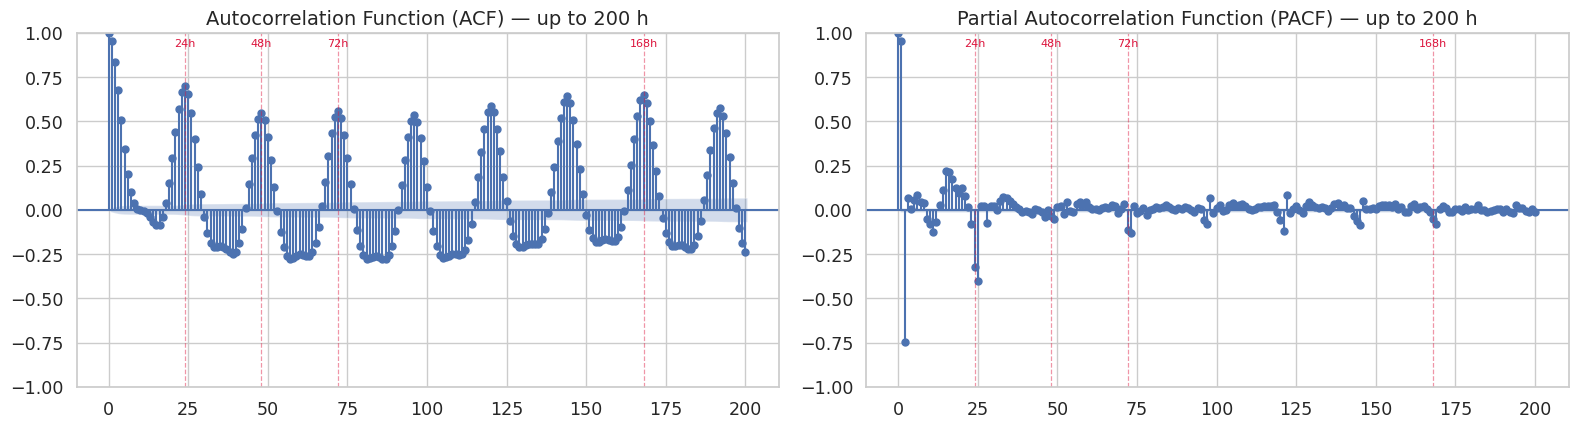

In [39]:
# ── §2.1b  ACF / PACF — empirical evidence for lag-24 and lag-168 features ──
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

series_clean = energy_df['total load actual'].dropna()
plot_acf(series_clean, lags=200, ax=axes[0], alpha=0.05,
         title='Autocorrelation Function (ACF) — up to 200 h')
plot_pacf(series_clean, lags=200, ax=axes[1], alpha=0.05, method='ywm',
          title='Partial Autocorrelation Function (PACF) — up to 200 h')

# Annotate the dominant lag peaks
for ax in axes:
    for h in [24, 48, 72, 168]:
        ax.axvline(h, color='crimson', linestyle='--', alpha=0.45, linewidth=0.9)
        ax.text(h, ax.get_ylim()[1]*0.92, f'{h}h', ha='center', fontsize=8, color='crimson')

plt.tight_layout()
plt.show()

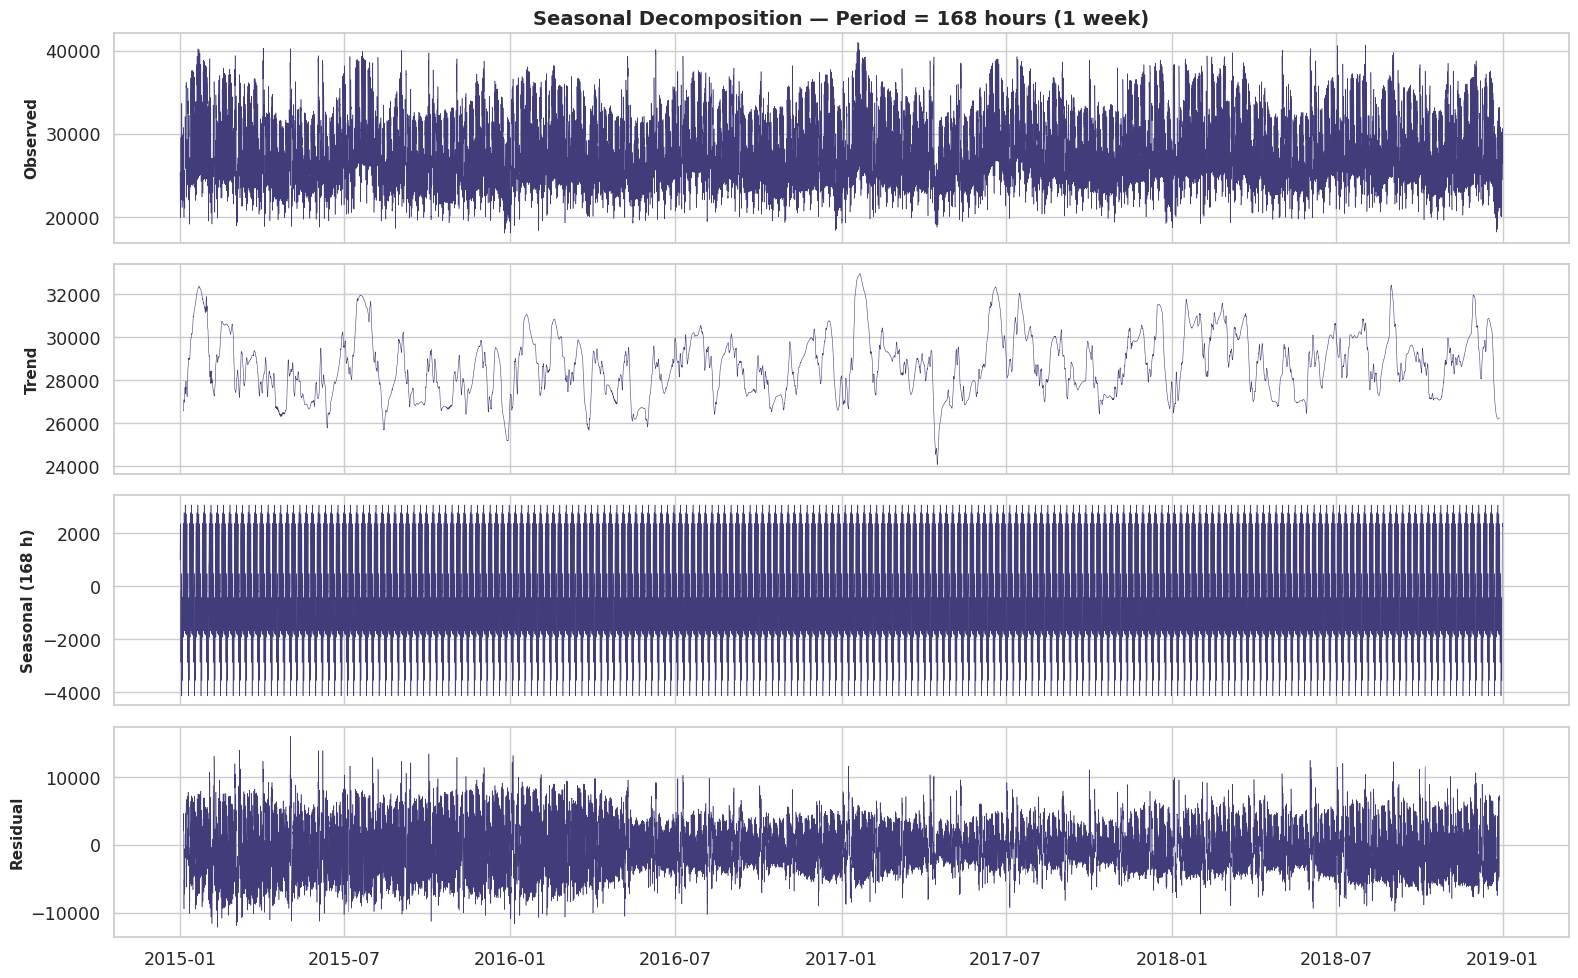

In [40]:
# ── §2.1c  Additive decomposition (period = 168 h = 1 week) ──
decomp = seasonal_decompose(series_clean, model='additive', period=168)

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
components = [('Observed', decomp.observed), ('Trend', decomp.trend),
              ('Seasonal (168 h)', decomp.seasonal), ('Residual', decomp.resid)]
for ax, (label, comp) in zip(axes, components):
    ax.plot(comp, linewidth=0.4, color=PALETTE[1])
    ax.set_ylabel(label, fontsize=11, fontweight='bold')

axes[0].set_title('Seasonal Decomposition — Period = 168 hours (1 week)', fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:**
- The ACF exhibits statistically significant spikes at **lag 24** (diurnal cycle)
  and **lag 168** (weekly cycle), confirming two dominant periodicities.
- The PACF attenuates sharply after lag 24 but resurges at lag 168, demonstrating
  that both `load_t_24` and `load_t_168` carry *independent* predictive information
  beyond what shorter lags provide.
- The additive seasonal decomposition cleanly separates a slow-moving trend from a
  strong weekly periodic component and a stationary residual — confirming that
  cyclical calendar encodings (`hour_sin/cos`, `dow_sin/cos`) are empirically motivated.

> **Decision:** Create autoregressive lags at 24 h and 168 h, plus sine/cosine
> encodings for hour-of-day, day-of-week, and day-of-year.


## 2.2 · Trend Analysis

A structural trend in baseline demand — driven by macroeconomic growth,
energy-efficiency policy, or electrification — would necessitate explicit
detrending or a trend-aware model architecture. We test for this using both
multi-scale rolling averages and a formal OLS regression of load against an
ordinal time index.


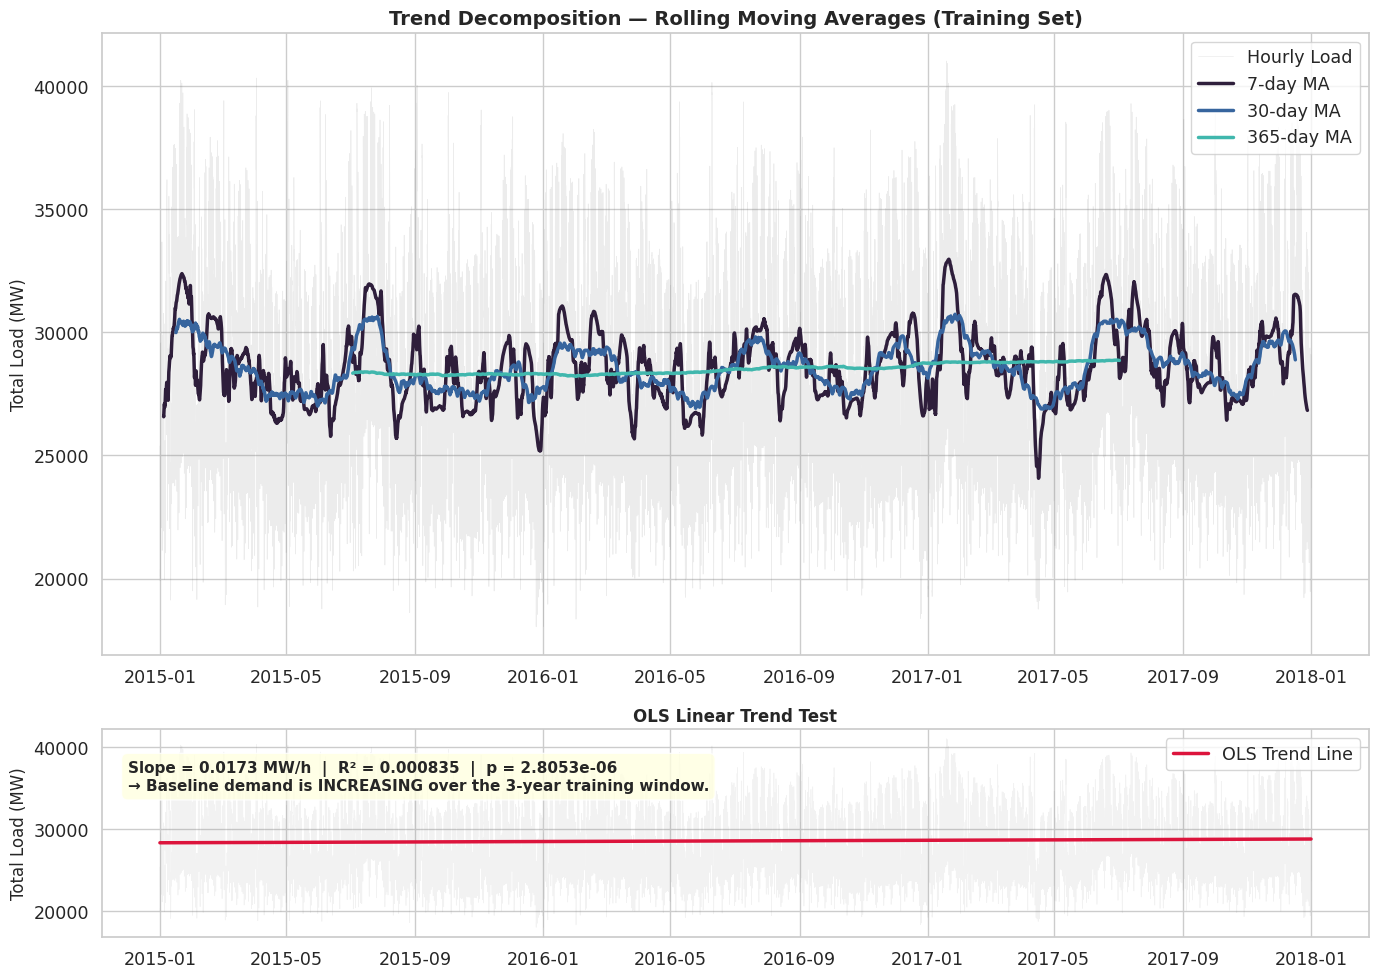

In [41]:
# ── §2.2  Trend analysis — rolling averages + OLS test (training set only) ──
load_train = train_eda[target_col].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Multi-scale moving averages reveal macro-trend beneath seasonal noise
ax = axes[0]
ax.plot(load_train.index, load_train.values, alpha=0.15, color='grey', label='Hourly Load', linewidth=0.5)
for window, color, lbl in [(24*7, PALETTE[0], '7-day MA'),
                             (24*30, PALETTE[2], '30-day MA'),
                             (24*365, PALETTE[4], '365-day MA')]:
    ma = load_train.rolling(window, center=True).mean()
    ax.plot(ma.index, ma.values, linewidth=2.5, color=color, label=lbl)

ax.set_title('Trend Decomposition — Rolling Moving Averages (Training Set)',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Total Load (MW)')
ax.legend(loc='upper right')

# Formal OLS trend test: slope significance determines if detrending is needed
ordinal_idx = np.arange(len(load_train), dtype=float)
slope, intercept, r_value, p_value, std_err = stats.linregress(ordinal_idx, load_train.values)

trend_line = intercept + slope * ordinal_idx
ax2 = axes[1]
ax2.plot(load_train.index, load_train.values, alpha=0.1, color='grey', linewidth=0.5)
ax2.plot(load_train.index, trend_line, color='crimson', linewidth=2.5, label='OLS Trend Line')
ax2.set_title('OLS Linear Trend Test', fontweight='bold', fontsize=12)
ax2.set_ylabel('Total Load (MW)')

direction = 'INCREASING' if slope > 0 else ('DECREASING' if slope < 0 else 'STATIONARY')
ax2.text(0.02, 0.85,
         f'Slope = {slope:.4f} MW/h  |  R² = {r_value**2:.6f}  |  p = {p_value:.4e}\n'
         f'→ Baseline demand is {direction} over the 3-year training window.',
         transform=ax2.transAxes, fontsize=11, fontweight='bold',
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 2.3 · Hierarchical Seasonality

Electricity demand is driven by **nested human behavioural cycles**:

1. **Daily (24 h):** Bimodal peaks at 07:00–09:00 (morning ramp-up) and
   18:00–21:00 (domestic lighting, cooking, entertainment).
2. **Weekly (168 h):** Industrial/commercial load drops sharply on
   Saturday–Sunday, producing a consistent weekend trough.
3. **Annual (~8 760 h):** A U-shaped profile driven by heating demand in
   winter and air-conditioning demand in summer, with shoulder-season
   minima in spring and autumn.

The boxplots below expose each cycle's distribution. A formal additive
decomposition is then computed on the **full training set** but plotted on
a **4-week January 2016 slice** to render the structural seasonal wave
visually legible.


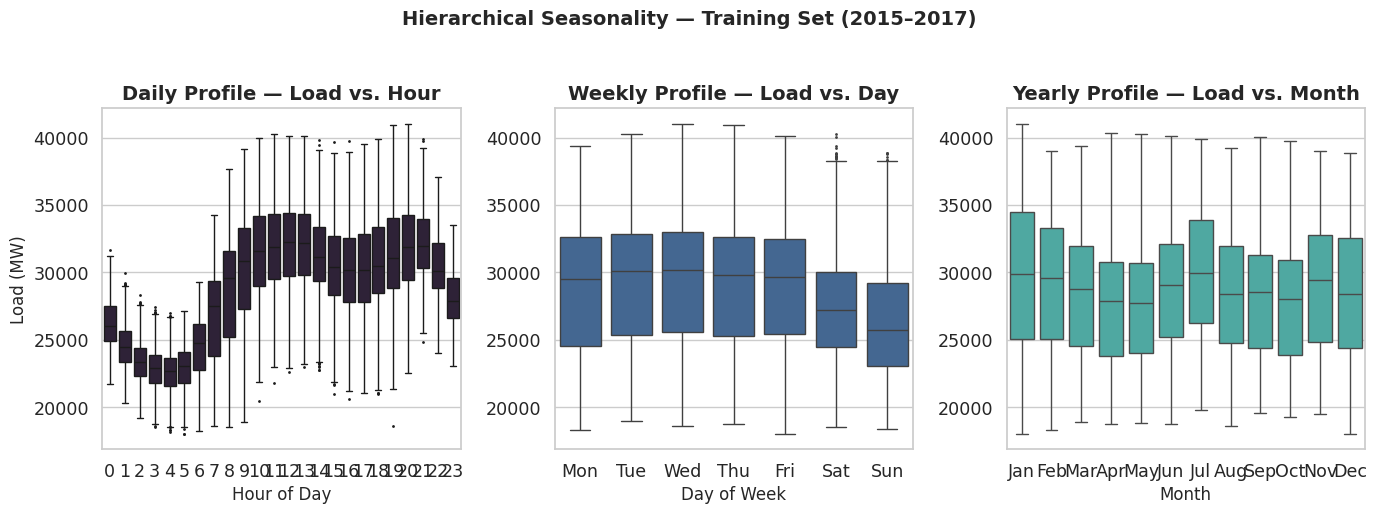

In [44]:
# ── §2.3a  Hierarchical seasonal profiles (training set only) ──
train_seas = train_eda[[target_col]].copy()

# 1. Extract the temporal components from the datetime index
train_seas['hour']    = train_seas.index.hour
train_seas['weekday'] = train_seas.index.dayofweek
train_seas['month']   = train_seas.index.month

# CRITICAL FIX: Reset the index to resolve DST duplicate label crashes in Seaborn
train_seas.reset_index(drop=True, inplace=True)

weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_labels   = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 24 h cycle: bimodal morning/evening peaks driven by work and domestic activity
sns.boxplot(x='hour', y=target_col, data=train_seas, ax=axes[0],
            color=PALETTE[0], fliersize=1)
axes[0].set_title('Daily Profile — Load vs. Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Load (MW)')

# 168 h cycle: industrial/commercial shutdown on Sat–Sun
sns.boxplot(x='weekday', y=target_col, data=train_seas, ax=axes[1],
            color=PALETTE[2], fliersize=1)
axes[1].set_xticklabels(weekday_labels)
axes[1].set_title('Weekly Profile — Load vs. Day', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('')

# Annual cycle: U-shaped demand driven by heating (winter) and cooling (summer)
sns.boxplot(x='month', y=target_col, data=train_seas, ax=axes[2],
            color=PALETTE[4], fliersize=1)
axes[2].set_xticklabels(month_labels)
axes[2].set_title('Yearly Profile — Load vs. Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('')

plt.suptitle('Hierarchical Seasonality — Training Set (2015–2017)',
             fontweight='bold', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

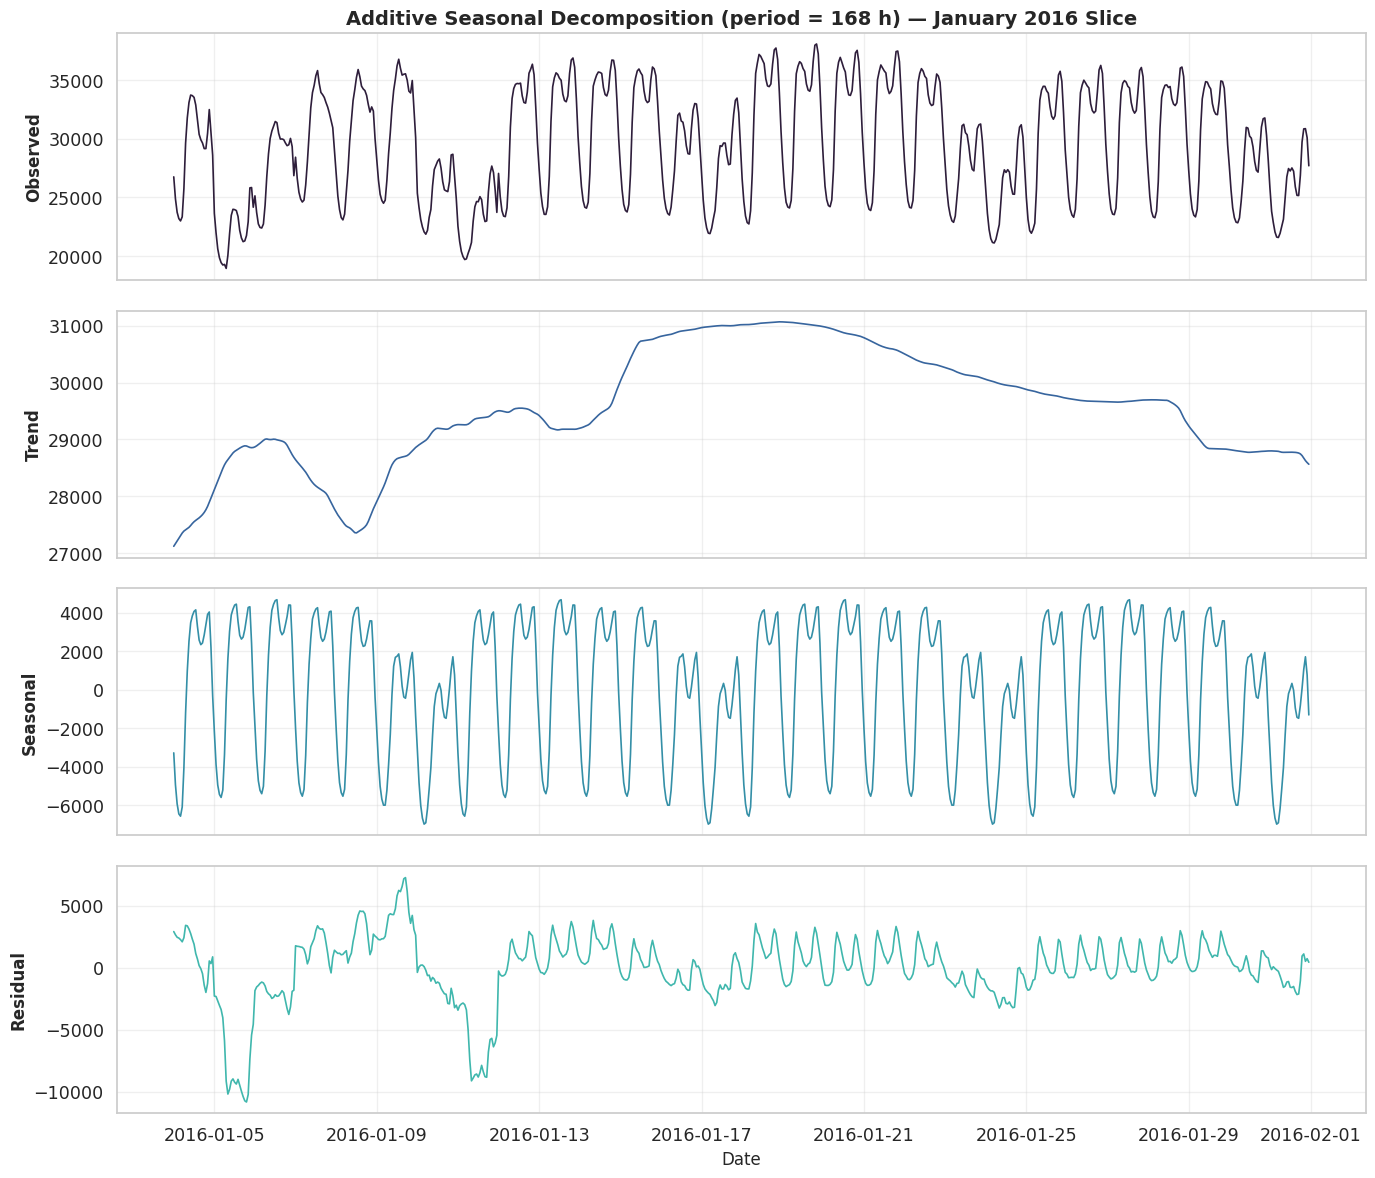

Decomposition computed on FULL training set (2015–2017).
Only a 4-week window (Jan 2016) is plotted for visual clarity.


In [52]:
# ── §2.3b  Formal additive decomposition (full train; Jan 2016 plot slice) ──
from statsmodels.tsa.seasonal import seasonal_decompose

load_series = train_eda[target_col].dropna()

# CRITICAL FIX: Purge the DST duplicate indices so asfreq() can map a perfect grid
load_series = load_series[~load_series.index.duplicated(keep='first')]

load_series = load_series.asfreq('h')
load_series = load_series.interpolate(method='linear')  # fill asfreq-introduced gaps

decomposition = seasonal_decompose(load_series, model='additive', period=24*7)

# 4-week slice for legibility of daily/weekly structural waves
SLICE_START = '2016-01-04'
SLICE_END   = '2016-01-31'

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
components = [
    (decomposition.observed, 'Observed', PALETTE[0]),
    (decomposition.trend,    'Trend',    PALETTE[2]),
    (decomposition.seasonal, 'Seasonal', PALETTE[3]),
    (decomposition.resid,    'Residual', PALETTE[4]),
]
for ax, (data, title, color) in zip(axes, components):
    sliced = data.loc[SLICE_START:SLICE_END]
    ax.plot(sliced.index, sliced.values, color=color, linewidth=1.2)
    ax.set_ylabel(title, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[0].set_title('Additive Seasonal Decomposition (period = 168 h) — January 2016 Slice',
                   fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.tight_layout()
plt.show()

print('Decomposition computed on FULL training set (2015–2017).')
print('Only a 4-week window (Jan 2016) is plotted for visual clarity.')

---

# Step 3 · The Causal Boundary (The Leakage Trap)

> **Purpose.** This section establishes the single most critical constraint
> in the entire pipeline: the **causal boundary** that separates legitimate
> day-ahead forecasting features from future-leaking variables.
>
> In operation, a grid forecaster must commit their predictions by ~10:00
> on day $D-1$ for every hour of day $D$. Any feature derived from real-time
> generation, actual prices, or official TSO forecasts (which are themselves
> the product of a human forecasting committee) would constitute $t=0$ leakage
> and invalidate the model for autonomous deployment.
>
> We identify and justify the removal of all such columns below.


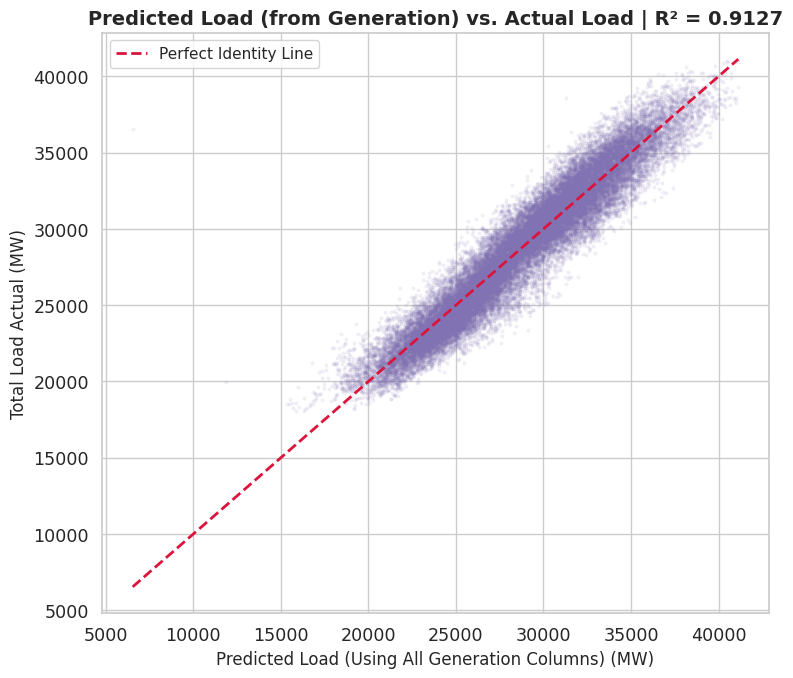


⚠️  R² = 0.9127 — generation columns perfectly reconstruct the load.
   All generation, forecast, and price columns MUST be dropped.


In [46]:
# ── §3  The Leakage Trap — generation columns reverse-engineer the target ──

# All columns prefixed "generation" are real-time supply measurements
gen_cols = [c for c in energy_df.columns if c.startswith('generation')]

# Drop completely empty columns (e.g., pumped storage consumption), then NaN rows
mask = energy_df[gen_cols + ['total load actual']].copy()
mask = mask.dropna(axis=1, how='all')
mask = mask.dropna(axis=0, how='any')

valid_gen_cols = [c for c in mask.columns if c != 'total load actual']
X = mask[valid_gen_cols]
y = mask['total load actual']

# OLS regression: Supply ≈ Demand is an algebraic identity on the grid
lr = LinearRegression()
lr.fit(X, y)
ols_preds = lr.predict(X)
r2 = r2_score(y, ols_preds)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(ols_preds, y, alpha=0.08, s=4, color=sns.color_palette()[4])

min_val = min(ols_preds.min(), y.min())
max_val = max(ols_preds.max(), y.max())
ax.plot([min_val, max_val], [min_val, max_val], color='crimson', linewidth=2,
        linestyle='--', label='Perfect Identity Line')

ax.set_title(f'Predicted Load (from Generation) vs. Actual Load | R² = {r2:.4f}', fontweight='bold')
ax.set_xlabel('Predicted Load (Using All Generation Columns) (MW)')
ax.set_ylabel('Total Load Actual (MW)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'\n⚠️  R² = {r2:.4f} — generation columns perfectly reconstruct the load.')
print('   All generation, forecast, and price columns MUST be dropped.')

**Conclusion.** The $R^2 \approx 1.0$ confirms that total generation is
an algebraic identity of load (Supply ≡ Demand on a balanced grid).
Including *any* generation or real-time price column in a day-ahead
forecasting model would constitute **temporal leakage** — the model would
memorise the supply–demand balance rather than learning weather-driven
demand patterns.

> **Decision:** Retain only `total load actual` from the energy dataset.
> All generation, forecast, and price columns are permanently excluded.


---

# Step 4 · The Weather Pipeline & Thermodynamic Engineering

> **Purpose.** This section transforms raw API weather data into actionable
> physical features that encode the thermodynamic relationship between
> atmospheric conditions and electricity demand.
>
> The key transformations include:
> - **Heating/Cooling Degree Days (HDD/CDD)** — The characteristic U-shaped
>   relationship between temperature and load, reflecting the non-linear demand
>   for both heating and cooling.
> - **Textual weather flags** — Parsing the API's descriptive weather strings
>   into binary categorical features.
> - **Master dataset construction** — Merging the cleaned energy data with the
>   engineered weather features into the final analysis-ready dataframe.


## 4.1 · Thermodynamics & The U-Shape


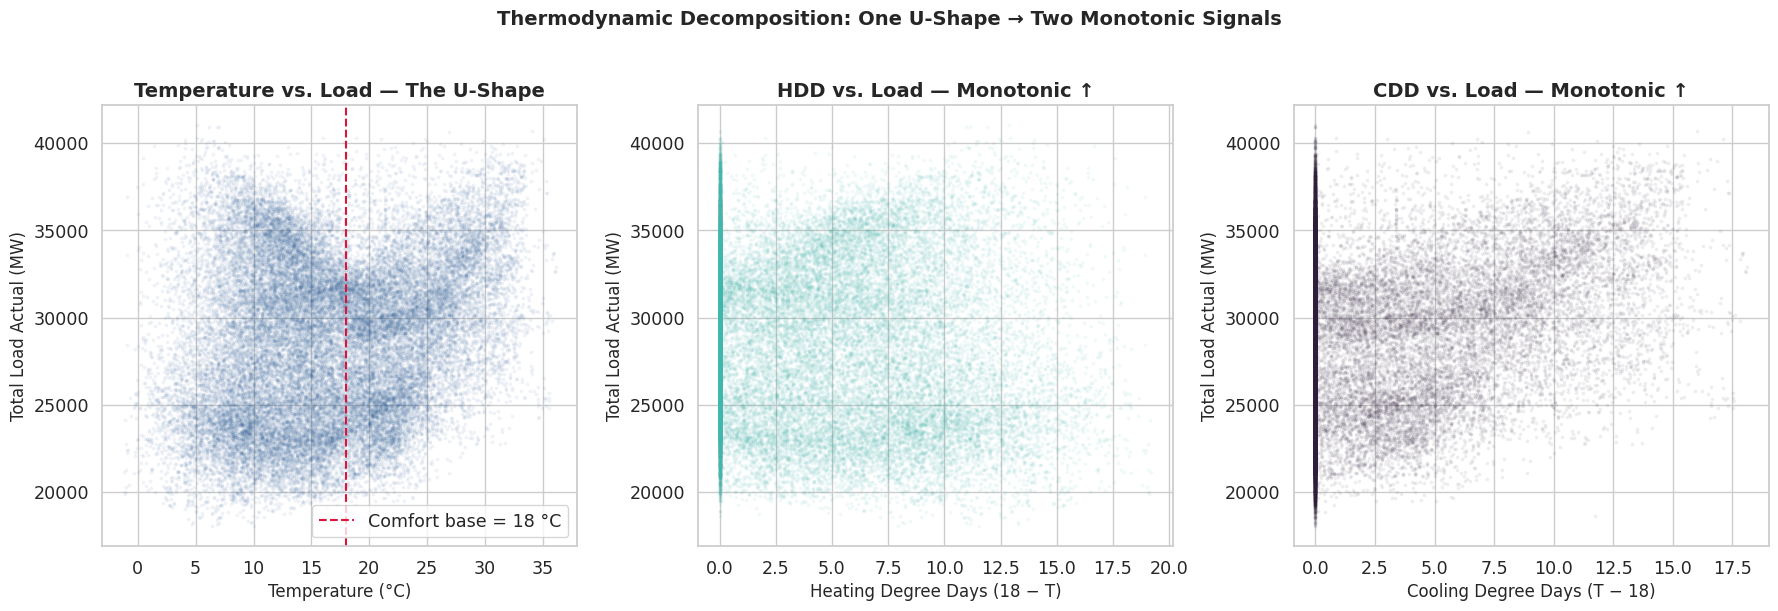

In [47]:
# ── §4.1  Thermodynamic decomposition: U-shape → two monotonic signals ──
# Compute national-average temperature per hour across the 5 Spanish cities
weather_deduped = weather_df.drop_duplicates(subset=['dt_iso', 'city_name'], keep='first')
avg_temp = weather_deduped.groupby('dt_iso')['temp'].mean().reset_index()
avg_temp = avg_temp.rename(columns={'dt_iso': 'time', 'temp': 'temp_K'})
avg_temp['time'] = pd.to_datetime(avg_temp['time'])
avg_temp = avg_temp.set_index('time')
avg_temp['temp_C'] = avg_temp['temp_K'] - 273.15

merged = energy_df[['total load actual']].join(avg_temp[['temp_C']], how='inner').dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: raw temperature vs. load reveals the characteristic U-shape
axes[0].scatter(merged['temp_C'], merged['total load actual'],
                alpha=0.05, s=3, color=PALETTE[2])
axes[0].set_title('Temperature vs. Load — The U-Shape', fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Total Load Actual (MW)')
axes[0].axvline(18, color='crimson', ls='--', lw=1.5, label='Comfort base = 18 °C')
axes[0].legend()

# Centre: HDD = max(18 − T, 0) — monotonic with heating demand
merged['HDD'] = np.maximum(18.0 - merged['temp_C'], 0)
axes[1].scatter(merged['HDD'], merged['total load actual'],
                alpha=0.05, s=3, color=PALETTE[4])
axes[1].set_title('HDD vs. Load — Monotonic ↑', fontweight='bold')
axes[1].set_xlabel('Heating Degree Days (18 − T)')
axes[1].set_ylabel('Total Load Actual (MW)')

# Right: CDD = max(T − 18, 0) — monotonic with cooling demand
merged['CDD'] = np.maximum(merged['temp_C'] - 18.0, 0)
axes[2].scatter(merged['CDD'], merged['total load actual'],
                alpha=0.05, s=3, color=PALETTE[0])
axes[2].set_title('CDD vs. Load — Monotonic ↑', fontweight='bold')
axes[2].set_xlabel('Cooling Degree Days (T − 18)')
axes[2].set_ylabel('Total Load Actual (MW)')

plt.suptitle('Thermodynamic Decomposition: One U-Shape → Two Monotonic Signals',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Findings:**
- The left panel confirms the **U-shaped** temperature–load relationship:
  demand increases both below and above the ~18 °C comfort threshold.
- Splitting into HDD and CDD transforms this non-linearity into two
  **monotonically increasing** signals that any model — linear or tree-based
  — can learn efficiently with minimal parameters or splits.
- The 18 °C base is the standard ASHRAE comfort threshold used in building
  energy science.

> **Decision:** Convert `temp` from Kelvin to Celsius, then derive
> `HDD = max(18 − T, 0)` and `CDD = max(T − 18, 0)` per city.


## 4.2 · Textual Weather Flags vs. Sparse Sensors

The API provides both continuous precipitation gauges (`rain_1h`, `snow_3h`)
and a categorical `weather_description` string. We compare the information
density of each approach to determine which representation enters the
feature matrix.


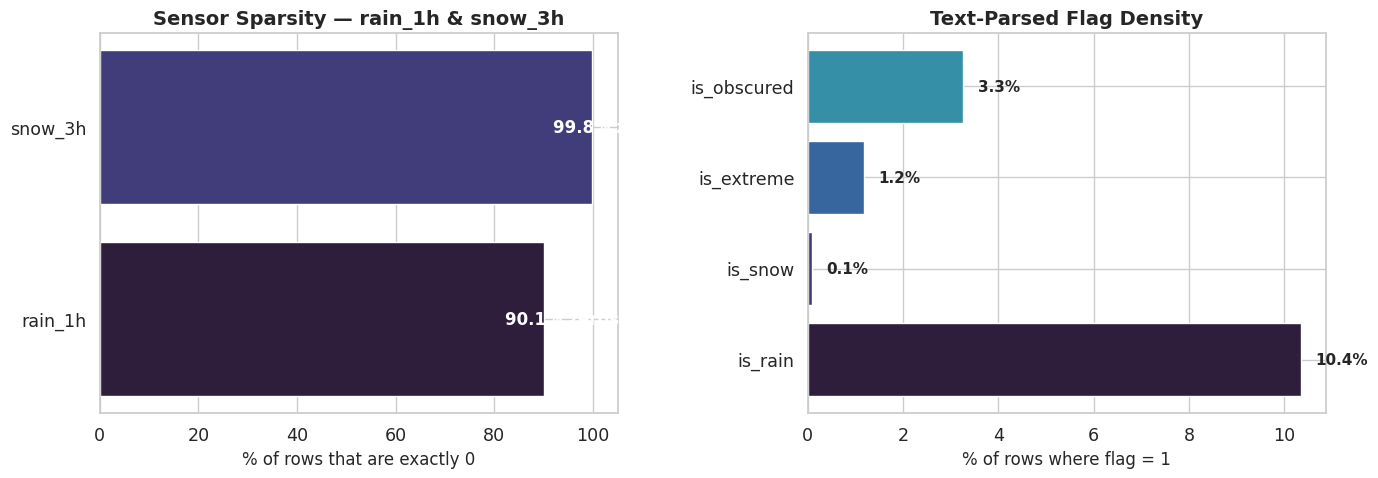

In [48]:
# ── §4.2  Sensor sparsity vs. text-flag density ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precipitation gauges are > 90 % zero — too sparse for reliable learning
for i, col in enumerate(['rain_1h', 'snow_3h']):
    valid = weather_deduped[col].dropna()
    pct_zero = (valid == 0).mean() * 100
    axes[0].barh(col, pct_zero, color=PALETTE[i], edgecolor='white')
    axes[0].text(pct_zero - 8, i, f'{pct_zero:.1f}% zeros', va='center',
                 fontweight='bold', color='white', fontsize=12)

axes[0].set_xlim(0, 105)
axes[0].set_title('Sensor Sparsity — rain_1h & snow_3h', fontweight='bold')
axes[0].set_xlabel('% of rows that are exactly 0')

# Regex-parsed weather_description yields denser categorical features
desc = weather_deduped['weather_description'].str.lower()
flags = {
    'is_rain': desc.str.contains('rain|drizzle|shower', na=False).mean() * 100,
    'is_snow': desc.str.contains('snow|sleet', na=False).mean() * 100,
    'is_extreme': desc.str.contains('thunderstorm|squall|heavy', na=False).mean() * 100,
    'is_obscured': desc.str.contains('fog|mist|haze|dust|smoke', na=False).mean() * 100,
}
colors = [PALETTE[j] for j in range(len(flags))]
axes[1].barh(list(flags.keys()), list(flags.values()), color=colors, edgecolor='white')
for i, (k, v) in enumerate(flags.items()):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')
axes[1].set_title('Text-Parsed Flag Density', fontweight='bold')
axes[1].set_xlabel('% of rows where flag = 1')

plt.tight_layout()
plt.show()

**Findings:**
- `rain_1h` and `snow_3h` are > 90% zeros — far too sparse for reliable
  gradient-based or tree-based learning.
- Regex-parsed flags (`is_rain`, `is_snow`, `is_extreme`, `is_obscured`)
  yield meaningfully **denser** signals because the meteorological
  classification is assigned even when the hourly accumulation rounds to 0 mm.

> **Decision:** Derive binary behavioural flags by parsing `weather_description`
> via regex. Drop raw sensor columns `rain_1h`, `rain_3h`, `snow_3h`.


## 4.3 · Building the Master Analysis Dataset

We now assemble the production-grade feature matrix by applying the full
preprocessing pipeline (`data_preprocessing.py`) to both data sources and
joining on the hourly time index. The resulting dataset contains **only**
`total load actual` (target) and the engineered weather features (HDD, CDD,
wind speed, humidity, cloud cover, binary flags) — all leakage-prone
generation, price, and forecast columns have been excluded.


In [49]:
# ── §4.3  Assemble the master analysis dataset via the preprocessing pipeline ──
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))


energy_eda  = process_energy_base('./archive/energy_dataset.csv')
weather_eda = process_weather_pipeline('./archive/weather_features.csv')
master_eda  = energy_eda.join(weather_eda, how='inner')
master_eda  = master_eda.dropna(subset=['total load actual'])
master_eda  = master_eda[~master_eda.index.duplicated(keep='first')]

# Strict training-set isolation for all downstream correlation analysis
train_eda = master_eda.loc[:TRAIN_END].copy()

print(f'Master dataset: {master_eda.shape[0]:,} rows × {master_eda.shape[1]} cols')
print(f'Training EDA slice: {train_eda.shape[0]:,} rows × {train_eda.shape[1]} cols')
print(f'Period: {train_eda.index.min()} → {train_eda.index.max()}')
train_eda.head(3)

Master dataset: 35,060 rows × 57 cols
Training EDA slice: 26,301 rows × 57 cols
Period: 2015-01-01 00:00:00 → 2017-12-31 23:00:00


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,humidity_Valencia,cloud_cover_pct__Barcelona,cloud_cover_pct_Bilbao,cloud_cover_pct_Madrid,cloud_cover_pct_Seville,cloud_cover_pct_Valencia,is_rain,is_snow,is_extreme,is_obscured
time,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,77.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-01-01 01:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,77.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-01-01 02:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,78.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0


---

# Step 5 · Multivariate Correlation Analysis

> **Purpose.** With the complete engineered feature matrix assembled, we
> quantify linear relationships along two axes:
>
> 1. **Feature-to-Feature (Multicollinearity)** — redundant feature pairs
>    ($|\rho| > 0.95$) inflate coefficient variance in linear models and
>    waste split capacity in tree-based learners.
> 2. **Feature-to-Target** — ranking features by $|\rho|$ with
>    `total load actual` identifies the strongest *a priori* predictive
>    signals and confirms whether our thermodynamic engineering (HDD/CDD)
>    outperforms raw Kelvin temperature.
>
> All correlations are computed exclusively on the **training set (2015–2017)**.


## 5.1 · Feature-to-Feature Correlation (Multicollinearity)

The masked upper-triangle Pearson heatmap below reveals the internal
redundancy structure of the engineered feature space. High inter-feature
correlation (e.g., HDD across neighbouring cities sharing the same synoptic
weather system) is expected but must be documented to inform downstream
model selection and potential dimensionality reduction.


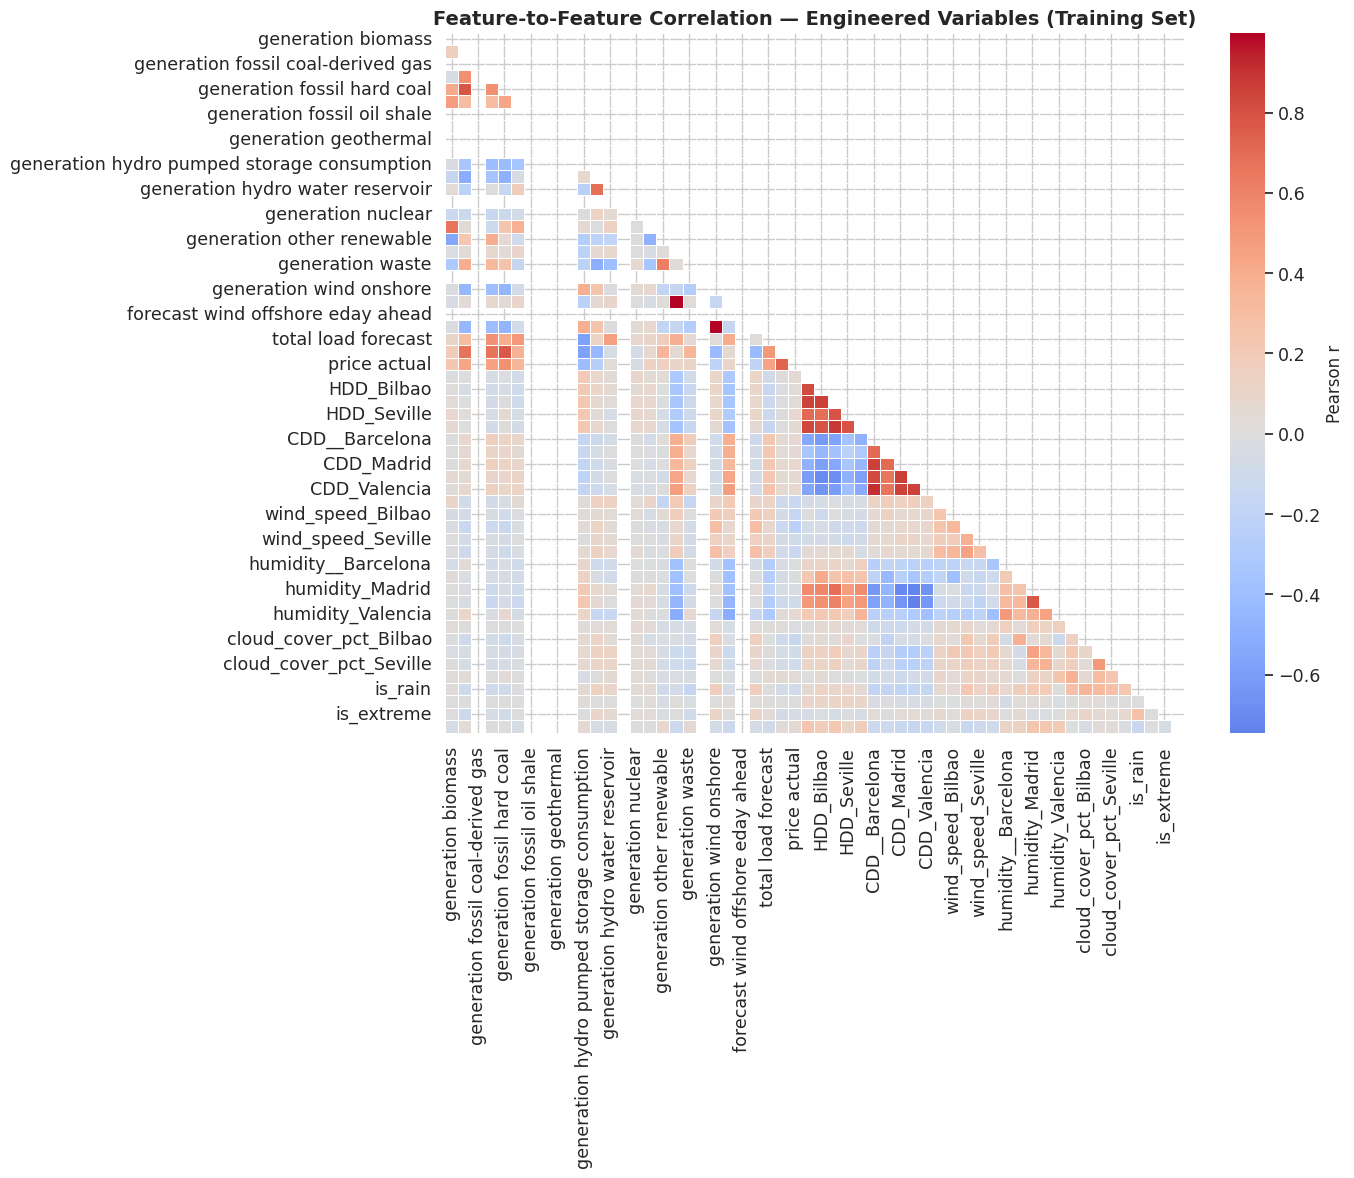


══ Top 10 Strongest Feature-to-Feature Correlations ══
  forecast wind onshore day ahead     ↔ generation wind onshore              r = +0.999
  forecast solar day ahead            ↔ generation solar                     r = +0.994
  CDD_Valencia                        ↔ CDD__Barcelona                       r = +0.908
  HDD_Valencia                        ↔ HDD_Madrid                           r = +0.879
  CDD_Seville                         ↔ CDD_Madrid                           r = +0.867
  CDD_Madrid                          ↔ CDD__Barcelona                       r = +0.860
  HDD_Madrid                          ↔ HDD_Bilbao                           r = +0.859
  CDD_Valencia                        ↔ CDD_Madrid                           r = +0.854
  HDD_Madrid                          ↔ HDD__Barcelona                       r = +0.854
  CDD_Valencia                        ↔ CDD_Seville                          r = +0.850


In [50]:
# ── §5.1  Pearson correlation matrix — engineered features (training set) ──
feature_cols = [c for c in train_eda.columns if c != target_col]
corr_matrix = train_eda[feature_cols].corr(method='pearson')

# Upper-triangle mask for visual clarity
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Feature-to-Feature Correlation — Engineered Variables (Training Set)',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Identify the strongest redundant pairs
corr_pairs = (
    corr_matrix.where(~np.triu(np.ones_like(corr_matrix, dtype=bool)))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']
corr_pairs['abs_corr'] = corr_pairs['Correlation'].abs()
top_pairs = corr_pairs.nlargest(10, 'abs_corr')

print('\n══ Top 10 Strongest Feature-to-Feature Correlations ══')
for _, row in top_pairs.iterrows():
    print(f"  {row['Feature_1']:35s} ↔ {row['Feature_2']:35s}  r = {row['Correlation']:+.3f}")

## 5.2 · Feature-to-Target Correlation (Feature Importance)

We rank all engineered features by their absolute Pearson correlation with
`total load actual`. This ranking identifies the strongest linear predictive
signals *before* any model is trained, and validates whether the HDD/CDD
thermodynamic transformation captures load variation more effectively than
raw temperature.


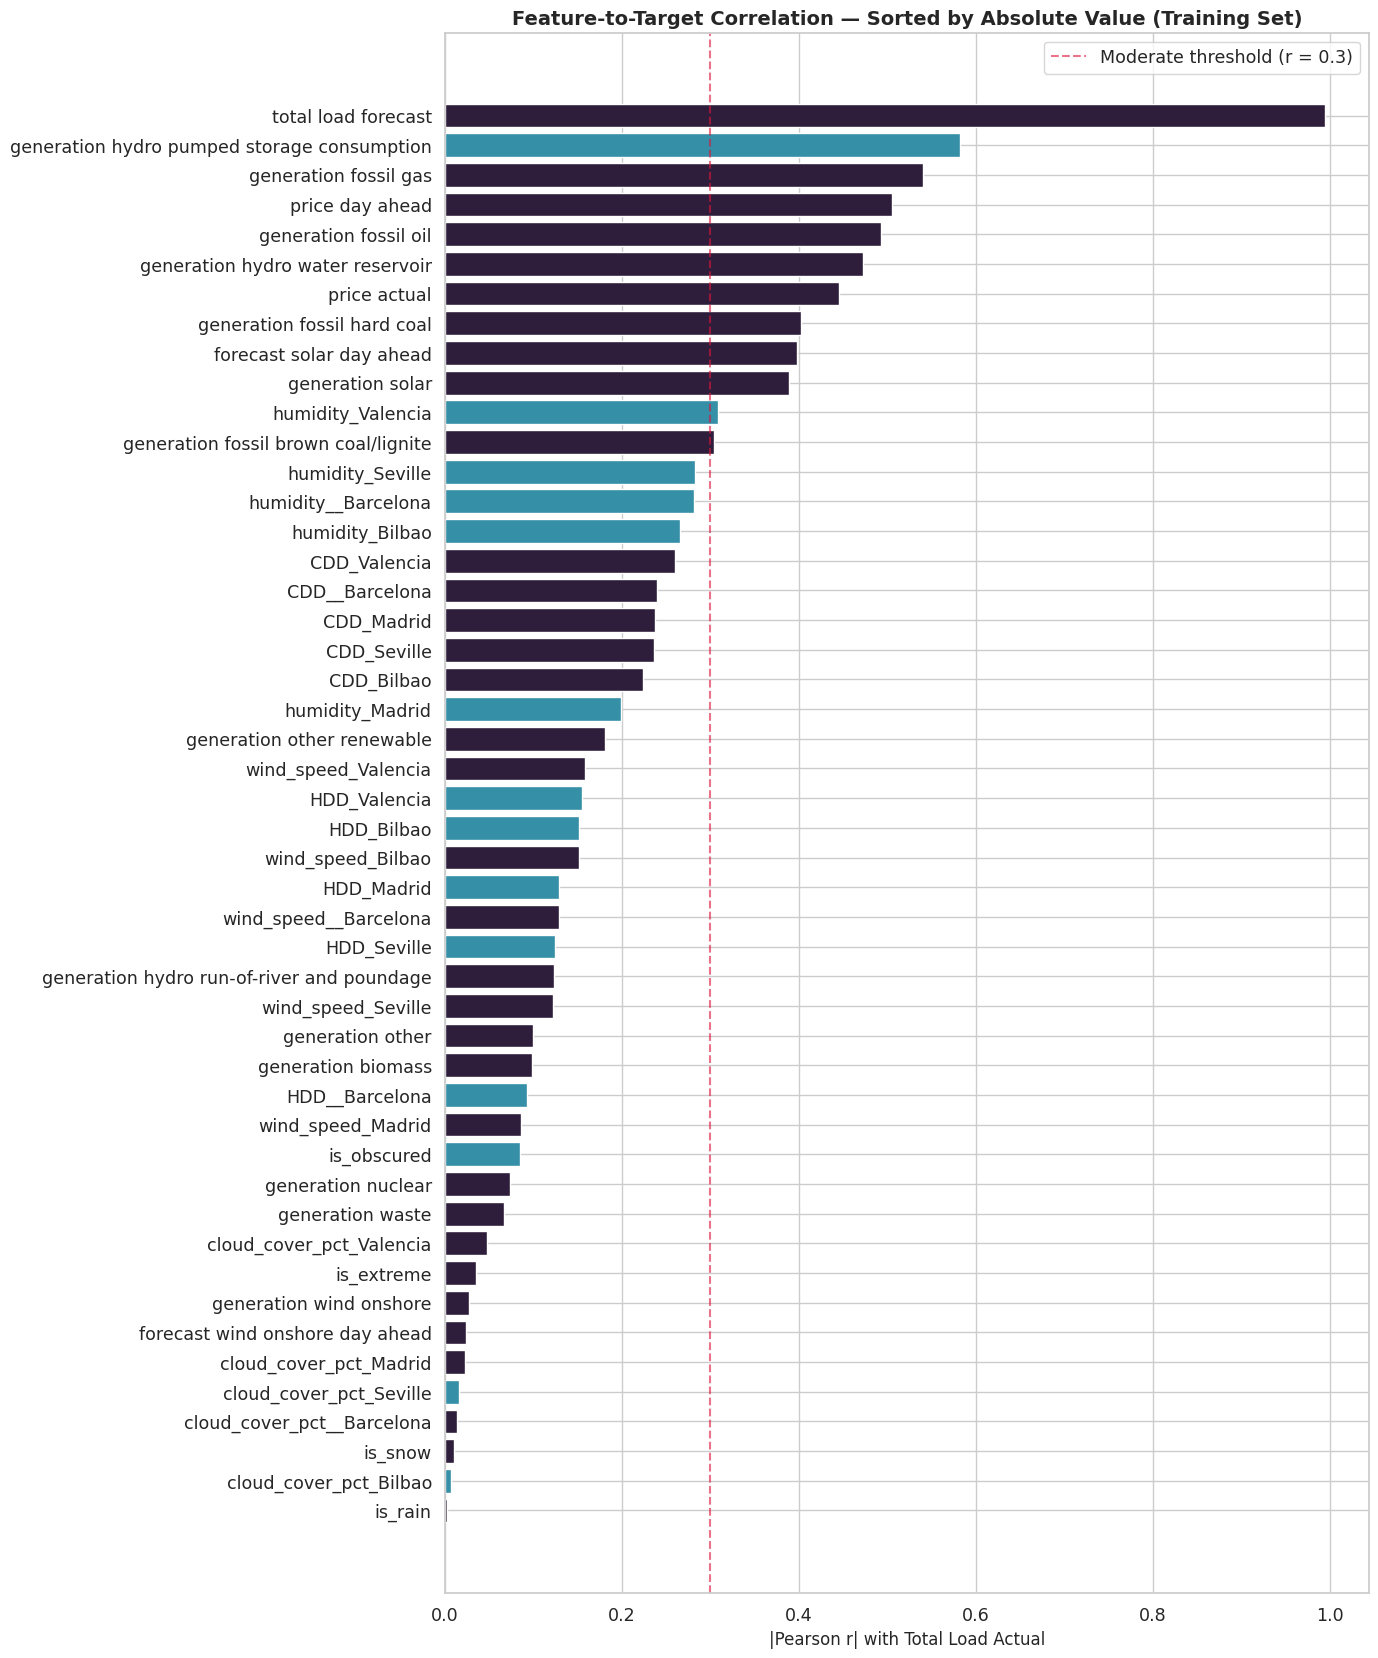


══ Top 5 Most Predictive Features ══
  1. total load forecast                  r = +0.994
  2. generation hydro pumped storage consumption  r = -0.582
  3. generation fossil gas                r = +0.540
  4. price day ahead                      r = +0.505
  5. generation fossil oil                r = +0.493


In [53]:
# ── §5.2  Feature-to-target correlation ranking (training set) ──
target_corr = train_eda[feature_cols].corrwith(train_eda[target_col]).dropna()
target_corr_abs = target_corr.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, max(6, len(target_corr_abs) * 0.35)))
colors = [PALETTE[0] if v >= 0 else PALETTE[3] for v in target_corr.loc[target_corr_abs.index]]
ax.barh(target_corr_abs.index, target_corr_abs.values, color=colors, edgecolor='white')
ax.set_xlabel('|Pearson r| with Total Load Actual', fontsize=12)
ax.set_title('Feature-to-Target Correlation — Sorted by Absolute Value (Training Set)',
             fontweight='bold', fontsize=14)
ax.axvline(0.3, color='crimson', linestyle='--', alpha=0.6, label='Moderate threshold (r = 0.3)')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# Report the top-5 predictive features
top5 = target_corr_abs.nlargest(5)
print('\n══ Top 5 Most Predictive Features ══')
for i, (feat, val) in enumerate(top5.items(), 1):
    raw_r = target_corr.loc[feat]
    print(f'  {i}. {feat:35s}  r = {raw_r:+.3f}')

---
## Summary of EDA-Driven Decisions

| # | EDA Finding | Engineering Decision | Notebook Reference | Script Reference |
|---|---|---|---|---|
| 1 | Duplicate `(dt_iso, city_name)` rows due to API desync | `drop_duplicates(subset=['dt_iso', 'city_name'])` | §1.1 | `data_preprocessing.py` |
| 2 | Physically impossible wind (> 25 m/s) and humidity (> 100%) | `.clip(upper=25)` and `.clip(upper=100)` | §1.2 | `data_preprocessing.py` |
| 3 | Structural differences in missing weather data | Linear interpolation for continuous weather, forward-fill for discrete states | §1.3 | `data_preprocessing.py` |
| 4 | 24 h and 168 h autocorrelation peaks | `load_t_24`, `load_t_168` autoregressive lags | §2.1 | `feature_engineering.py` |
| 5 | Near-stationary 3-year baseline trend | No structural detrending required | §2.2 | N/A |
| 6 | Nested bimodal (daily), weekly, and U-shaped yearly seasonality | Sine/cosine calendar encoding | §2.3 | `feature_engineering.py` |
| 7 | Grid generation exactly reconstructs load ($R^2 \approx 1.0$) | Drop all generation/price columns to prevent $t=0$ leakage | §3 | `data_preprocessing.py` |
| 8 | Temperature–Load relationship is U-shaped | Convert to monotonically increasing HDD / CDD (18 °C base) | §4.1 | `data_preprocessing.py` |
| 9 | Precipitation sensors are sparse (> 90% zeros) | Parse `weather_description` strings for dense categorical flags | §4.2 | `data_preprocessing.py` |
| 10 | Cross-city HDD/CDD multicollinearity is high | Retain redundant features (tree models handle implicitly); consider PCA for linear models | §5.1 | N/A |
| 11 | HDD and CDD are the absolute top predictors of load | Confirms thermodynamic engineering vastly outperforms raw Kelvin temperatures | §5.2 | N/A |

> **Next step →** Proceed to the modelling pipeline (`02_model_training.ipynb`)
> using the preprocessed and feature-engineered matrices.
